# HW1, задача 3: две массы, три пружины, $\mu = 110^\circ$

Постановка: две материальные точки, соединенные тремя пружинами:

- пружина 1: от левой стенки к массе $m_1$;
- пружина 2: между $m_1$ и $m_2$;
- пружина 3: от $m_2$ к якорю на наклонной стенке.

Как и в предыдущих задачах, используем:

1. символьный вывод (`sympy`) потенциальной энергии, сил и матрицы линеаризации;
2. численный поиск равновесия;
3. аналитическое решение линеаризованной системы (через нормальные моды);
4. сравнение явного/неявного/полуявного Эйлера и Верле на полной нелинейной системе.

Угол задаем: $\mu = 110^\circ$.

In [13]:
import math
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from scipy.optimize import root

try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("config", "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

sp.init_printing(use_latex="mathjax")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.35
plt.rcParams["grid.linestyle"] = "--"

MU_DEG = 110.0
MU = math.radians(MU_DEG)
print(f"mu = {MU_DEG} deg = {MU:.6f} rad")

mu = 110.0 deg = 1.919862 rad


## Геометрия и потенциал

Координаты масс:

$$
q_1=(x_1,y_1), \qquad q_2=(x_2,y_2).
$$

Фиксированные якоря:

$$
A=(0,0), \qquad B=(B_x,B_y),
$$

где $B$ задает правую наклонную пружину. Вектор от $m_2$ к якорю $B$ в базовой конфигурации направлен под углом $\mu$.

Длины пружин:

$$
\ell_1=\|q_1-A\|,\qquad \ell_2=\|q_2-q_1\|,\qquad \ell_3=\|q_2-B\|.
$$

Потенциальная энергия:

$$
V=\frac{k_1}{2}(\ell_1-L_{10})^2+\frac{k_2}{2}(\ell_2-L_{20})^2+\frac{k_3}{2}(\ell_3-L_{30})^2+m_1gy_1+m_2gy_2.
$$

Силы вычисляются через `sympy` как

$$
F=-\nabla V,
$$

а линеаризация вокруг равновесия — через матрицу Гессе $K=\nabla^2V$.

In [14]:
# Символьная модель (4 степени свободы)
x1, y1, x2, y2 = sp.symbols("x1 y1 x2 y2", real=True)

m1, m2, g = sp.symbols("m1 m2 g", positive=True, real=True)
k1, k2, k3 = sp.symbols("k1 k2 k3", positive=True, real=True)
L10, L20, L30 = sp.symbols("L10 L20 L30", positive=True, real=True)
Bx, By = sp.symbols("Bx By", real=True)

q = sp.Matrix([x1, y1, x2, y2])
A = sp.Matrix([0, 0])
B = sp.Matrix([Bx, By])
q1 = sp.Matrix([x1, y1])
q2 = sp.Matrix([x2, y2])

l1 = sp.sqrt(((q1 - A).T * (q1 - A))[0])
l2 = sp.sqrt(((q2 - q1).T * (q2 - q1))[0])
l3 = sp.sqrt(((q2 - B).T * (q2 - B))[0])

V = (
    sp.Rational(1, 2) * k1 * (l1 - L10) ** 2
    + sp.Rational(1, 2) * k2 * (l2 - L20) ** 2
    + sp.Rational(1, 2) * k3 * (l3 - L30) ** 2
    + m1 * g * y1
    + m2 * g * y2
)

F = -sp.Matrix([sp.diff(V, z) for z in (x1, y1, x2, y2)])
K = sp.hessian(V, (x1, y1, x2, y2))

print("Размерность F:", F.shape, "Размерность K:", K.shape)
print("Первые компоненты сил:")
display(F[:2, :])

Размерность F: (4, 1) Размерность K: (4, 4)
Первые компоненты сил:


⎡           ⎛          ___________⎞      ⎛          __________________________ ↪
⎢           ⎜         ╱   2     2 ⎟      ⎜         ╱           2             2 ↪
⎢     k₁⋅x₁⋅⎝-L₁₀ + ╲╱  x₁  + y₁  ⎠   k₂⋅⎝-L₂₀ + ╲╱  (-x₁ + x₂)  + (-y₁ + y₂)  ↪
⎢   - ───────────────────────────── - ──────────────────────────────────────── ↪
⎢               ___________                         __________________________ ↪
⎢              ╱   2     2                         ╱           2             2 ↪
⎢            ╲╱  x₁  + y₁                        ╲╱  (-x₁ + x₂)  + (-y₁ + y₂)  ↪
⎢                                                                              ↪
⎢              ⎛          ___________⎞      ⎛          _______________________ ↪
⎢              ⎜         ╱   2     2 ⎟      ⎜         ╱           2            ↪
⎢        k₁⋅y₁⋅⎝-L₁₀ + ╲╱  x₁  + y₁  ⎠   k₂⋅⎝-L₂₀ + ╲╱  (-x₁ + x₂)  + (-y₁ + y ↪
⎢-g⋅m₁ - ───────────────────────────── - ───────────────────────────────────── ↪
⎢                  _________

In [15]:
# Численные параметры (можно менять)
params = {
    m1: 1.0,
    m2: 1.0,
    g: 0.0,      # для задачи 3 обычно без гравитации
    k1: 30.0,
    k2: 30.0,
    k3: 30.0,
    L10: 1.00,
    L20: 1.00,
    L30: 1.20,
}

# Базовая геометрия для правого якоря
x1_ref, y1_ref = 1.00, 0.00
x2_ref, y2_ref = x1_ref + params[L20], 0.00
Bx_val = x2_ref + params[L30] * math.sin(MU)
By_val = y2_ref - params[L30] * math.cos(MU)

params[Bx] = Bx_val
params[By] = By_val

F_sub = F.subs(params)
K_sub = K.subs(params)
V_sub = V.subs(params)

F_num = sp.lambdify((x1, y1, x2, y2), F_sub, modules="numpy")
K_num = sp.lambdify((x1, y1, x2, y2), K_sub, modules="numpy")
V_num = sp.lambdify((x1, y1, x2, y2), V_sub, modules="numpy")


def force_np(q4):
    x1v, y1v, x2v, y2v = map(float, q4)
    return np.asarray(F_num(x1v, y1v, x2v, y2v), dtype=float).reshape(4)


guesses = [
    np.array([1.00, 0.00, 2.00, 0.00]),
    np.array([0.95, 0.05, 1.95, 0.02]),
    np.array([1.05, -0.05, 2.05, -0.03]),
]

sol = None
for guess in guesses:
    cand = root(force_np, guess)
    if cand.success and np.linalg.norm(force_np(cand.x)) < 1e-8:
        sol = cand
        break

if sol is None:
    raise RuntimeError("Равновесие не найдено. Попробуйте изменить guesses/params.")

q_eq = sol.x.astype(float)
K_eq = np.array(K_num(*q_eq), dtype=float)
M = np.diag([params[m1], params[m1], params[m2], params[m2]])

print("A =", np.array([0.0, 0.0]))
print("B =", np.array([Bx_val, By_val]))
print("q_eq =", q_eq)
print("|F(q_eq)| =", np.linalg.norm(force_np(q_eq)))
print("eig(K) =", np.linalg.eigvalsh(K_eq))

A = [0. 0.]
B = [3.12763114 0.41042417]
q_eq = [1.00000000e+00 0.00000000e+00 2.00000000e+00 1.29843013e-15]
|F(q_eq)| = 0.0
eig(K) = [7.54951657e-15 1.18539057e+00 3.00000000e+01 8.88146094e+01]


## Аналитика линеаризованной системы

Линеаризация около равновесия $q_0$:

$$
M\ddot\eta + K(q_0)\eta = 0,
$$

где

$$
\eta = q - q_0,\qquad M=\mathrm{diag}(m_1,m_1,m_2,m_2).
$$

Далее строим моды через симметричную форму

$$
S=M^{-1/2}KM^{-1/2},
$$

и решаем систему по модальным координатам.

omega = [8.68879541e-08 1.08875643e+00 5.47722558e+00 9.42415033e+00]


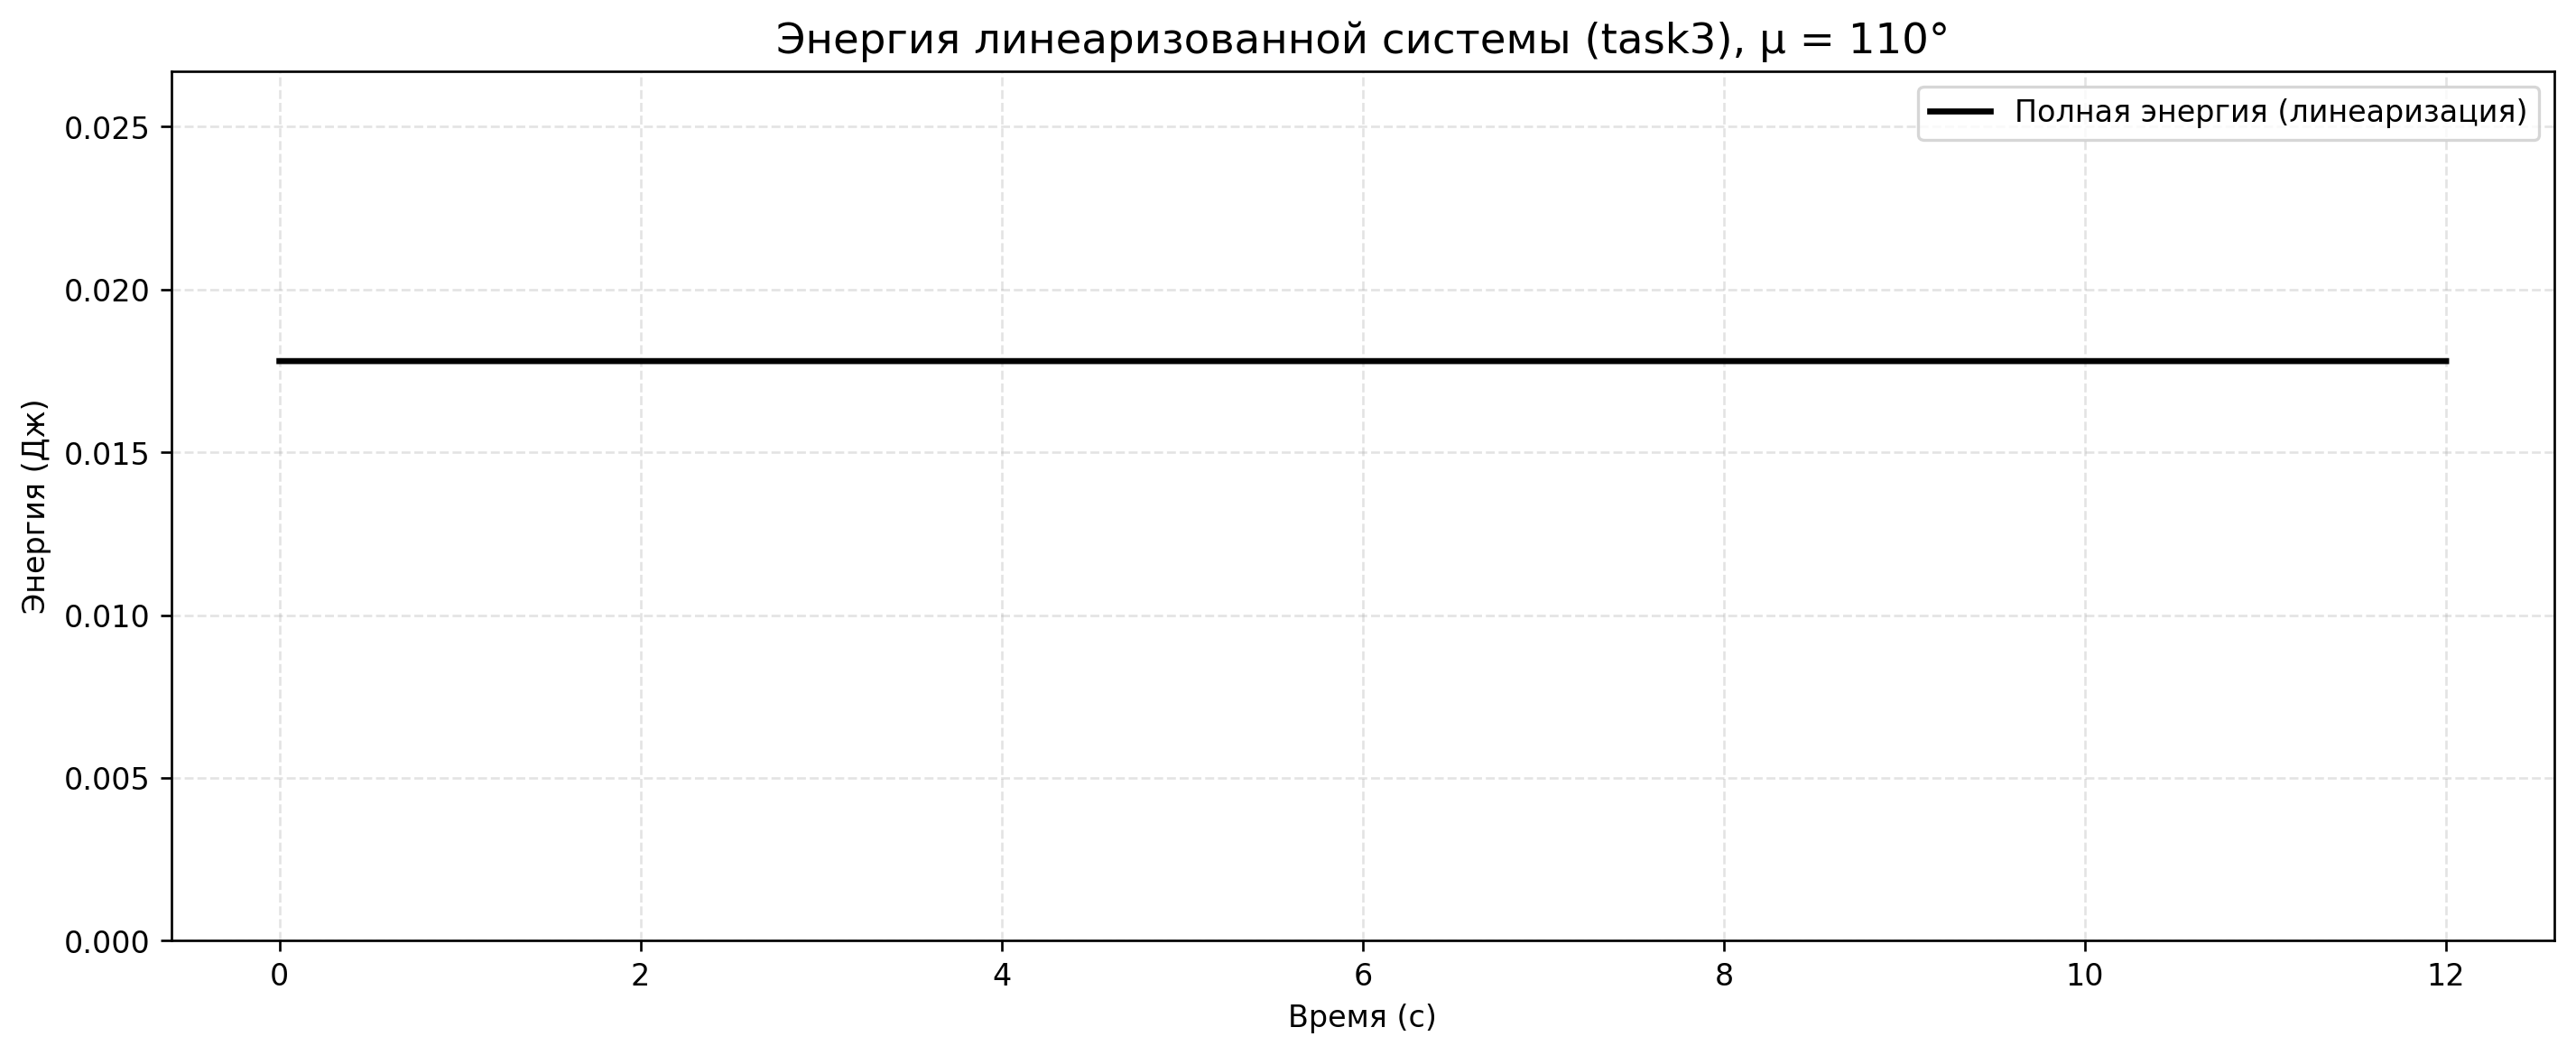

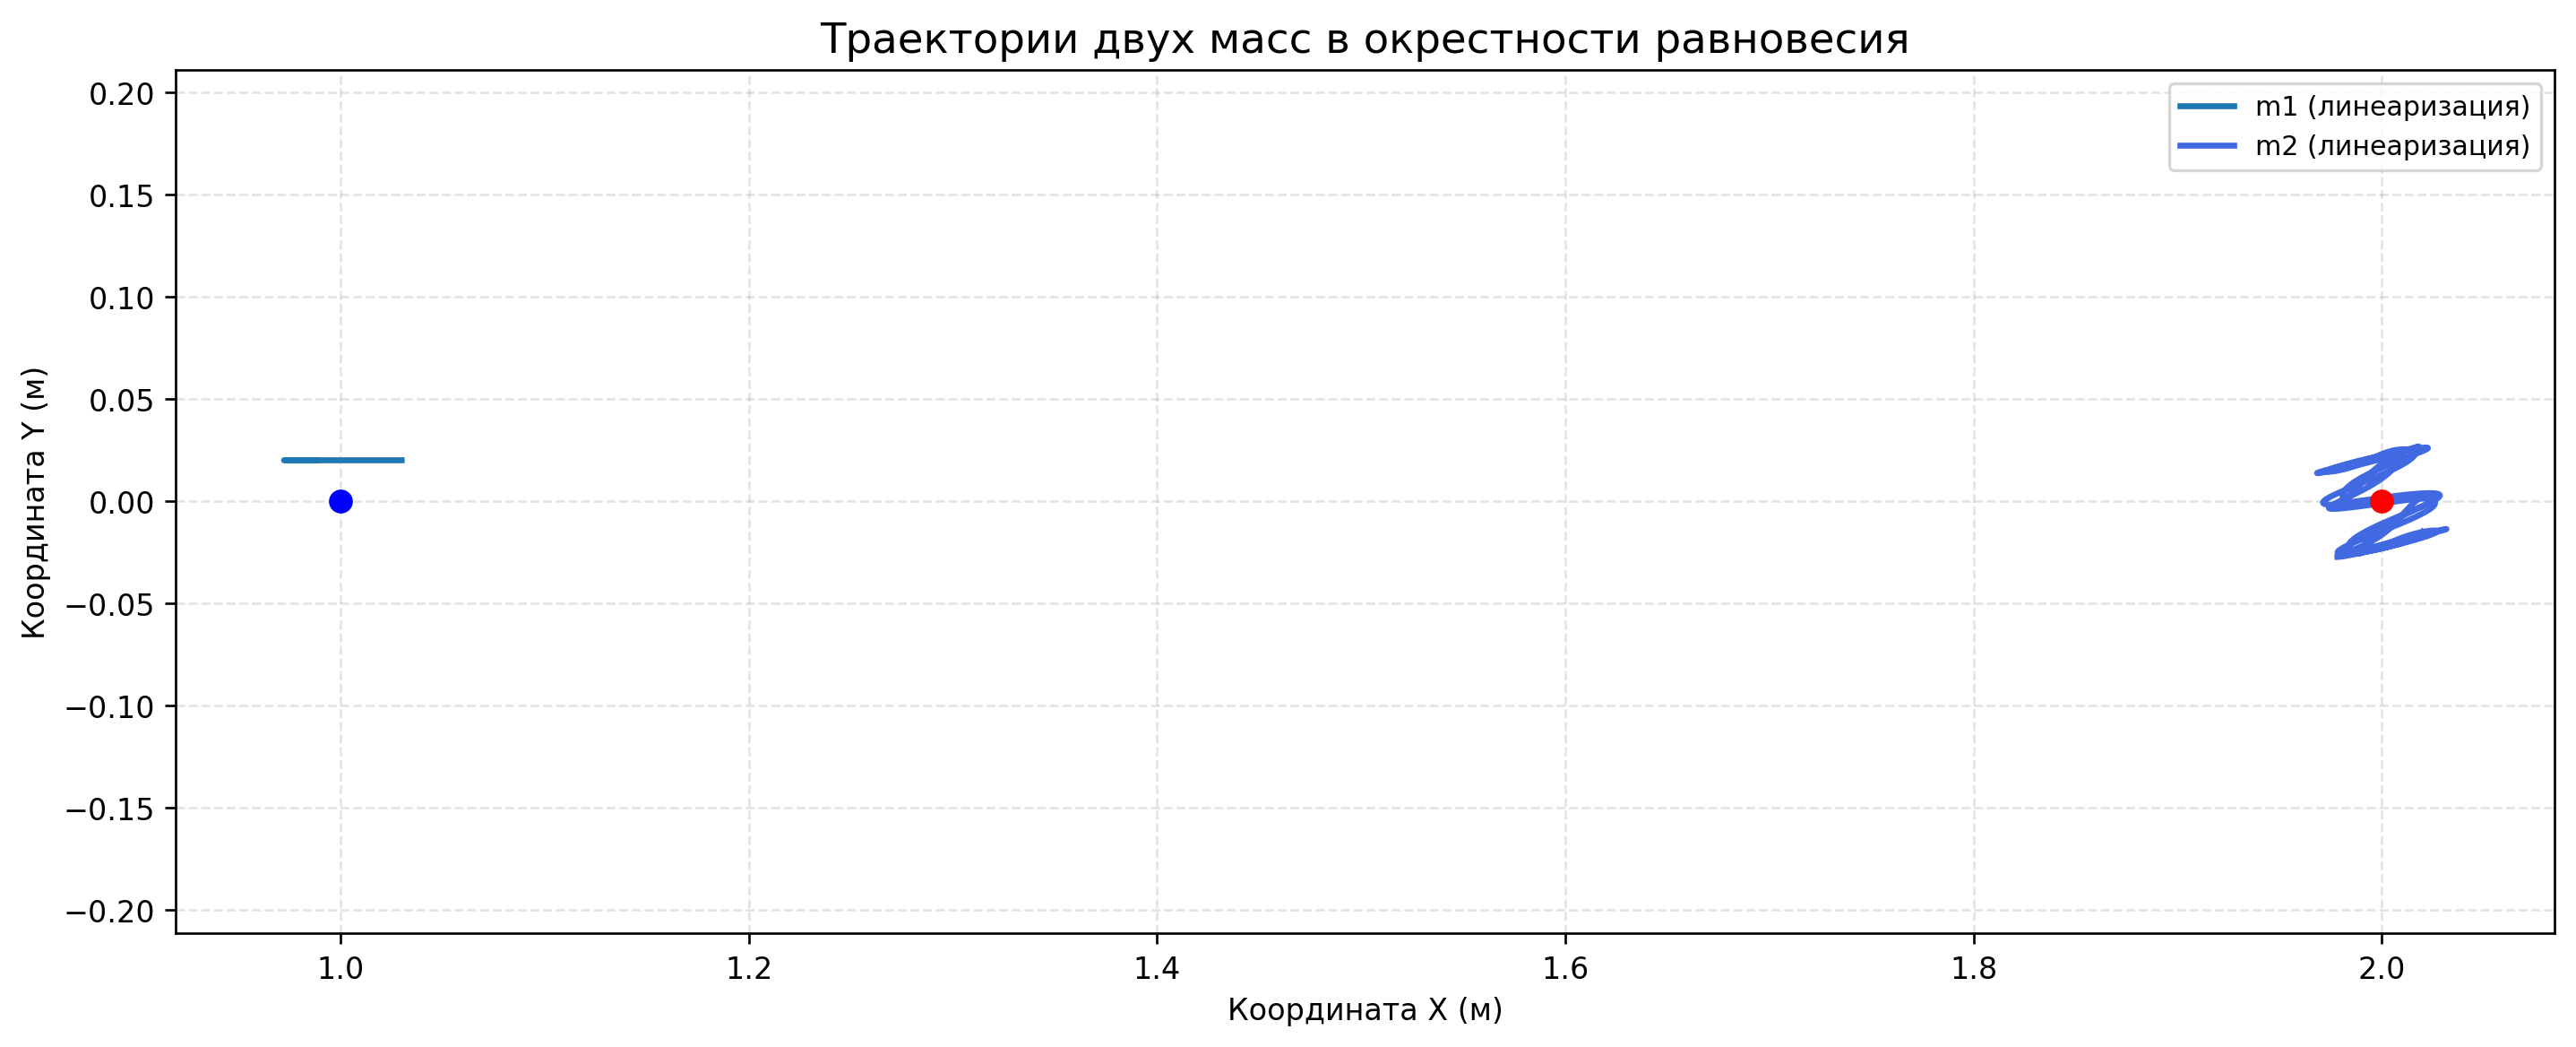

In [16]:
def linear_analytic_solution(ts, q0, v0, q_eq, K_eq, M):
    Minv_sqrt = np.diag(1.0 / np.sqrt(np.diag(M)))
    Msqrt = np.diag(np.sqrt(np.diag(M)))

    S = Minv_sqrt @ K_eq @ Minv_sqrt
    eigvals, U = np.linalg.eigh(S)
    if np.any(eigvals <= 0):
        raise RuntimeError("В линеаризации есть неположительные моды (неустойчивое равновесие).")

    omega = np.sqrt(eigvals)
    eta0 = q0 - q_eq

    q0m = U.T @ (Msqrt @ eta0)
    v0m = U.T @ (Msqrt @ v0)

    qmodal = np.cos(np.outer(ts, omega)) * q0m + np.sin(np.outer(ts, omega)) * (v0m / omega)
    vmodal = -np.sin(np.outer(ts, omega)) * (omega * q0m) + np.cos(np.outer(ts, omega)) * v0m

    eta = (Minv_sqrt @ U @ qmodal.T).T
    vel = (Minv_sqrt @ U @ vmodal.T).T
    pos = q_eq + eta
    return pos, vel, omega


ts = np.linspace(0.0, 12.0, 1600)
q0_linear = q_eq + np.array([0.03, 0.02, 0.02, -0.015])
v0_linear = np.zeros(4)

pos_lin, vel_lin, omega = linear_analytic_solution(ts, q0_linear, v0_linear, q_eq, K_eq, M)
eta_lin = pos_lin - q_eq

E_lin = 0.5 * np.einsum("ni,ij,nj->n", vel_lin, M, vel_lin) + 0.5 * np.einsum("ni,ij,nj->n", eta_lin, K_eq, eta_lin)

print("omega =", omega)

# Траектории обеих масс
x1_lin, y1_lin = pos_lin[:, 0], pos_lin[:, 1]
x2_lin, y2_lin = pos_lin[:, 2], pos_lin[:, 3]

plt.figure(figsize=(12, 5))
plt.plot(ts, E_lin, color="black", lw=2, label="Полная энергия (линеаризация)")
plt.title("Энергия линеаризованной системы (task3), μ = 110°", fontsize=14)
plt.xlabel("Время (с)")
plt.ylabel("Энергия (Дж)")
plt.ylim(0, float(np.max(E_lin)) * 1.5 + 1e-15)
plt.grid(True, linestyle="--")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(x1_lin, y1_lin, color="tab:blue", lw=2, label="m1 (линеаризация)")
plt.plot(x2_lin, y2_lin, color="royalblue", lw=2, label="m2 (линеаризация)")
plt.plot(q_eq[0], q_eq[1], "bo", markersize=7)
plt.plot(q_eq[2], q_eq[3], "ro", markersize=7)
# plt.plot([0.0], [0.0], "ks", markersize=5, label="якорь A")
# plt.plot([Bx_val], [By_val], "k^", markersize=6, label="якорь B")
plt.title("Траектории двух масс в окрестности равновесия", fontsize=14)
plt.xlabel("Координата X (м)")
plt.ylabel("Координата Y (м)")
plt.axis("equal")
plt.grid(True, linestyle="--")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

## Нелинейная система и численные методы

Для полной модели интегрируем

$$
\dot q = v,\qquad \dot v = M^{-1}F(q),
$$

где $q\in\mathbb{R}^4$, $v\in\mathbb{R}^4$.

Сравниваем методы:

- явный Эйлер;
- неявный Эйлер;
- полуявный Эйлер;
- velocity Verlet.

In [17]:
mass_vec = np.array([params[m1], params[m1], params[m2], params[m2]], dtype=float)

def acceleration(q4):
    return force_np(q4) / mass_vec


def total_energy(q4, v4):
    kinetic = 0.5 * np.sum(mass_vec * v4 * v4)
    potential = float(V_num(*q4))
    return kinetic + potential


def step_explicit_euler(q4, v4, h):
    a = acceleration(q4)
    return q4 + h * v4, v4 + h * a


def step_semi_implicit_euler(q4, v4, h):
    v_next = v4 + h * acceleration(q4)
    q_next = q4 + h * v_next
    return q_next, v_next


def step_implicit_euler(q4, v4, h):
    def residual(z):
        q_next = z[:4]
        v_next = z[4:]
        return np.concatenate([
            q_next - q4 - h * v_next,
            v_next - v4 - h * acceleration(q_next),
        ])

    q_guess, v_guess = step_semi_implicit_euler(q4, v4, h)
    sol_imp = root(residual, np.concatenate([q_guess, v_guess]), method="hybr")
    if not sol_imp.success:
        raise RuntimeError("Implicit Euler: root solver не сошелся")
    return sol_imp.x[:4], sol_imp.x[4:]


def step_velocity_verlet(q4, v4, h):
    a0 = acceleration(q4)
    q_next = q4 + h * v4 + 0.5 * h * h * a0
    a1 = acceleration(q_next)
    v_next = v4 + 0.5 * h * (a0 + a1)
    return q_next, v_next


METHODS = {
    "explicit": ("Явный Эйлер", step_explicit_euler),
    "implicit": ("Неявный Эйлер", step_implicit_euler),
    "semi": ("Полуявный Эйлер", step_semi_implicit_euler),
    "verlet": ("Верле", step_velocity_verlet),
}


def simulate_methods(q0, v0, h, T):
    steps = int(T / h) + 1
    time = np.linspace(0.0, h * (steps - 1), steps)
    results = {}

    for mid, (label, stepper) in METHODS.items():
        q_hist = np.zeros((steps, 4))
        v_hist = np.zeros((steps, 4))
        e_hist = np.zeros(steps)

        q_hist[0] = q0
        v_hist[0] = v0
        e_hist[0] = total_energy(q0, v0)

        q_cur, v_cur = q0.copy(), v0.copy()
        for i in range(1, steps):
            q_cur, v_cur = stepper(q_cur, v_cur, h)
            q_hist[i] = q_cur
            v_hist[i] = v_cur
            e_hist[i] = total_energy(q_cur, v_cur)

        results[mid] = {"label": label, "q": q_hist, "v": v_hist, "E": e_hist}

    return time, results


# Малое отклонение для сравнения с линеаризацией
v0_small = np.zeros(4)
time_small, results_small = simulate_methods(q0_linear.copy(), v0_small, h=0.004, T=12.0)

# Более заметное отклонение для сравнения методов
q0_methods = q_eq + np.array([0.10, 0.07, 0.08, -0.05])
v0_methods = np.array([0.00, 0.00, 0.06, -0.03])
time, results = simulate_methods(q0_methods, v0_methods, h=0.010, T=18.0)

print("Симуляции завершены")
for mid, r in results.items():
    dE = r["E"][-1] - r["E"][0]
    print(f"{r['label']:<18} dE = {dE:+.6e} J")

Симуляции завершены
Явный Эйлер        dE = +6.023017e+03 J
Неявный Эйлер      dE = -1.982859e-01 J
Полуявный Эйлер    dE = -2.884574e-03 J
Верле              dE = -1.131021e-04 J


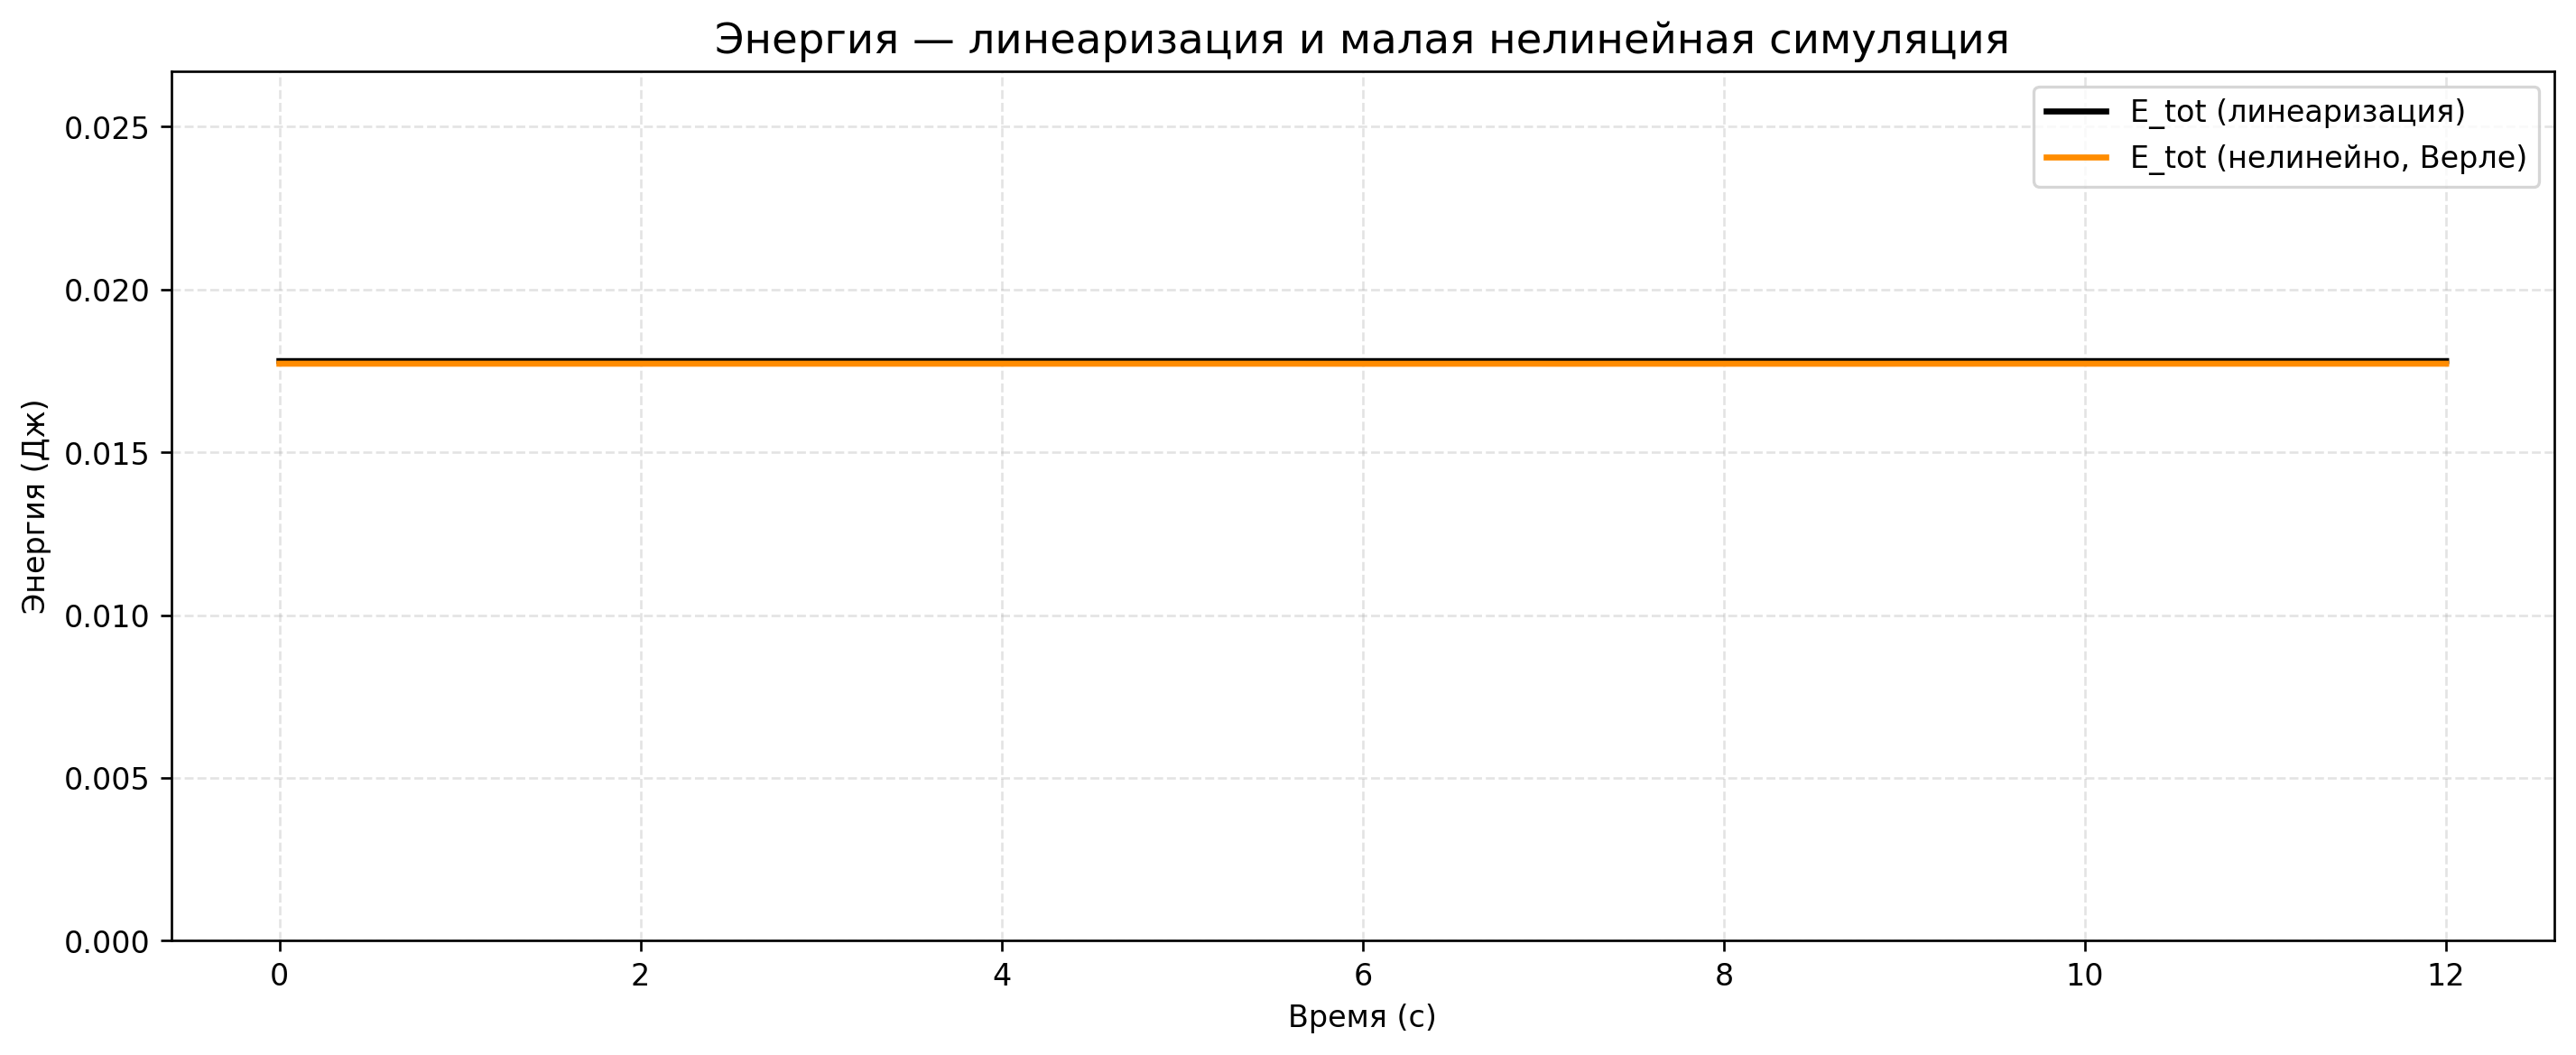

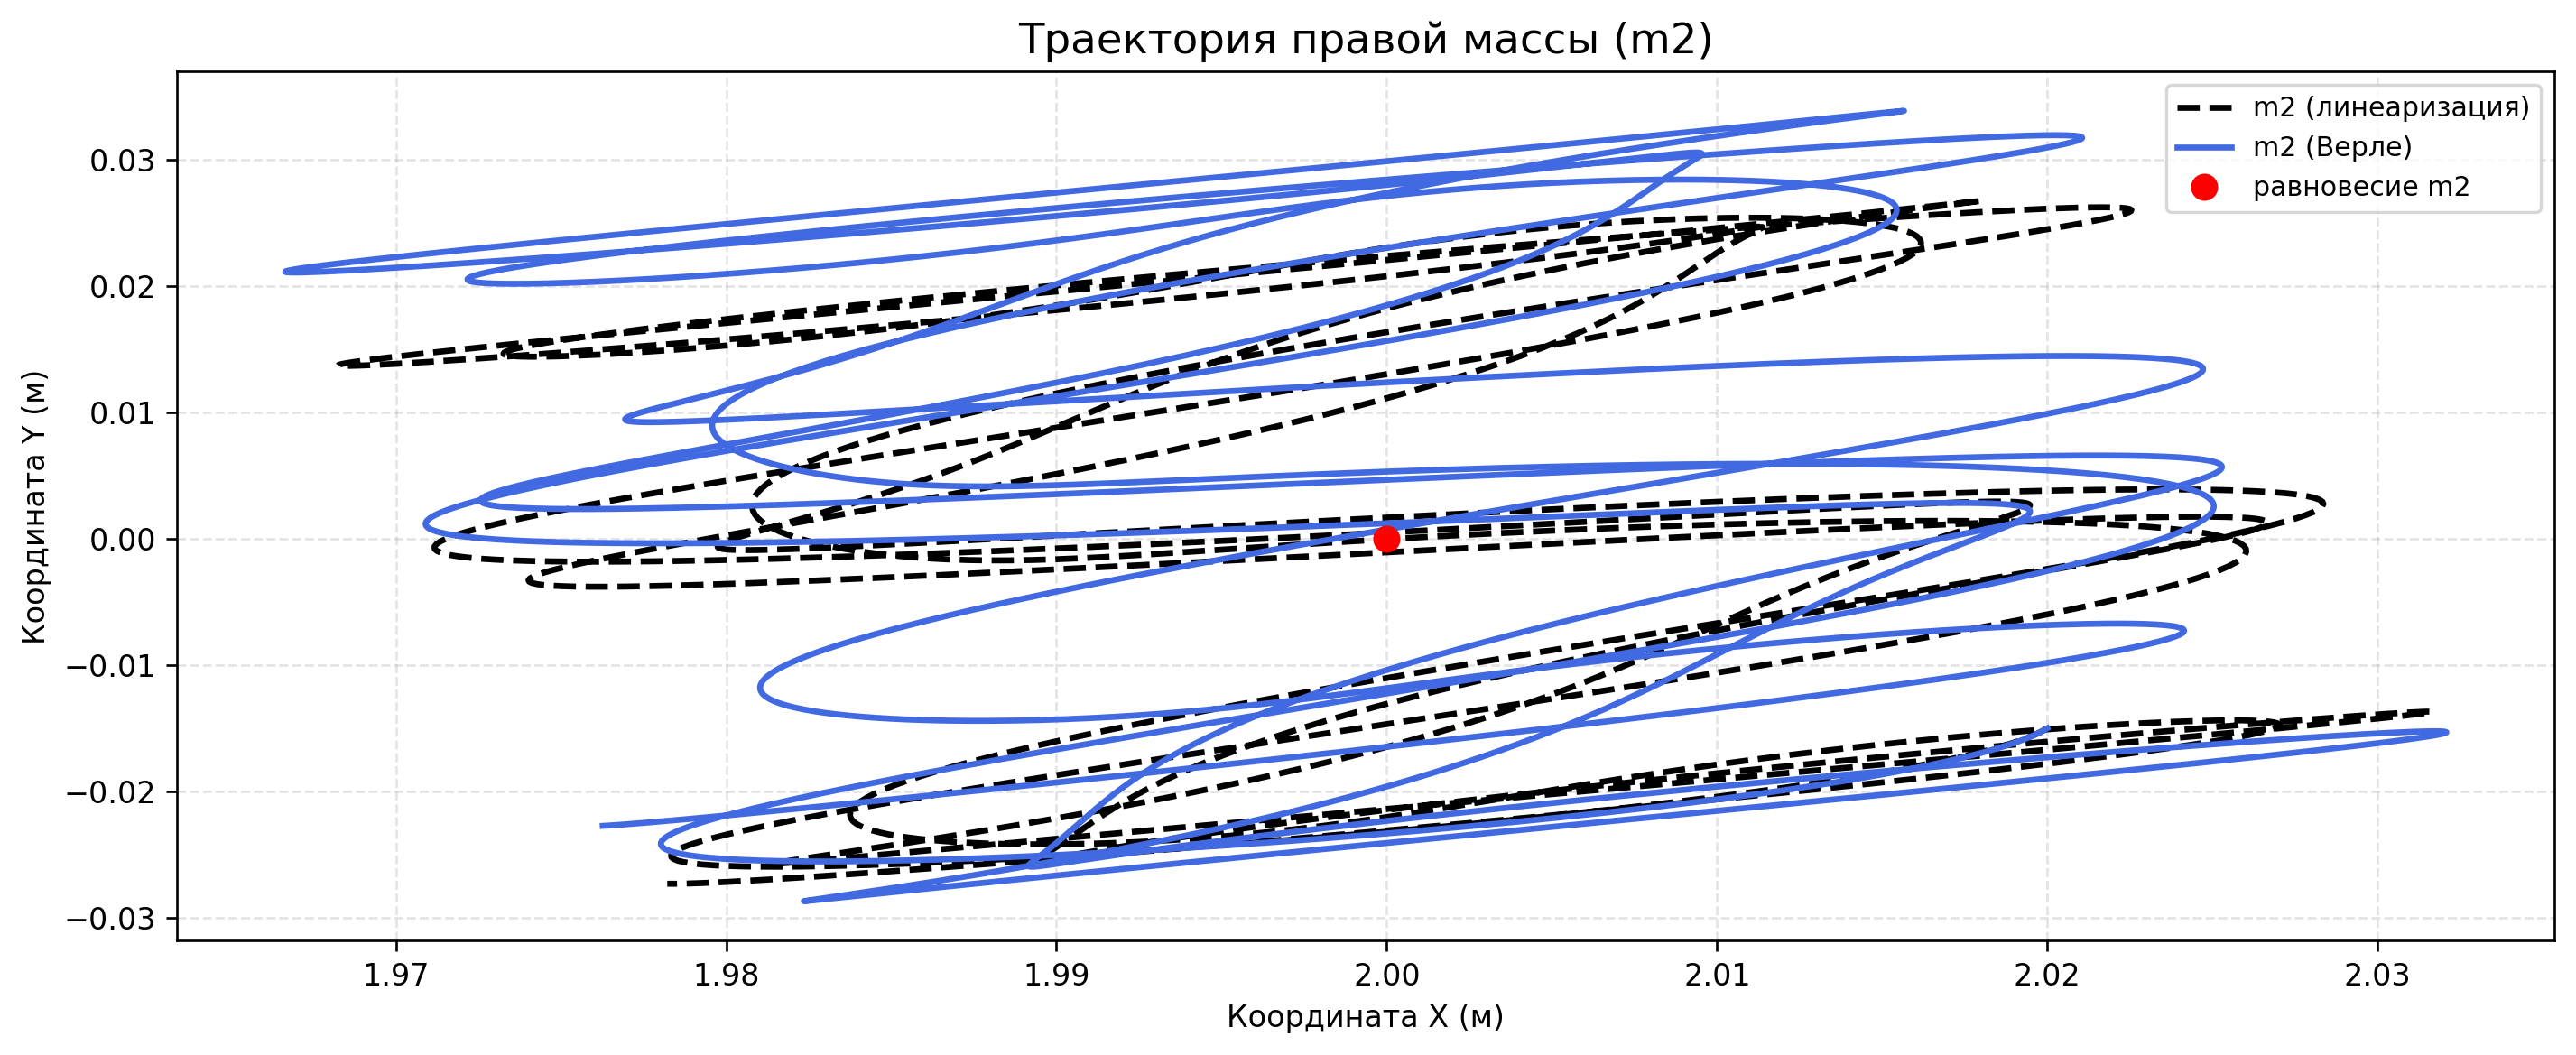

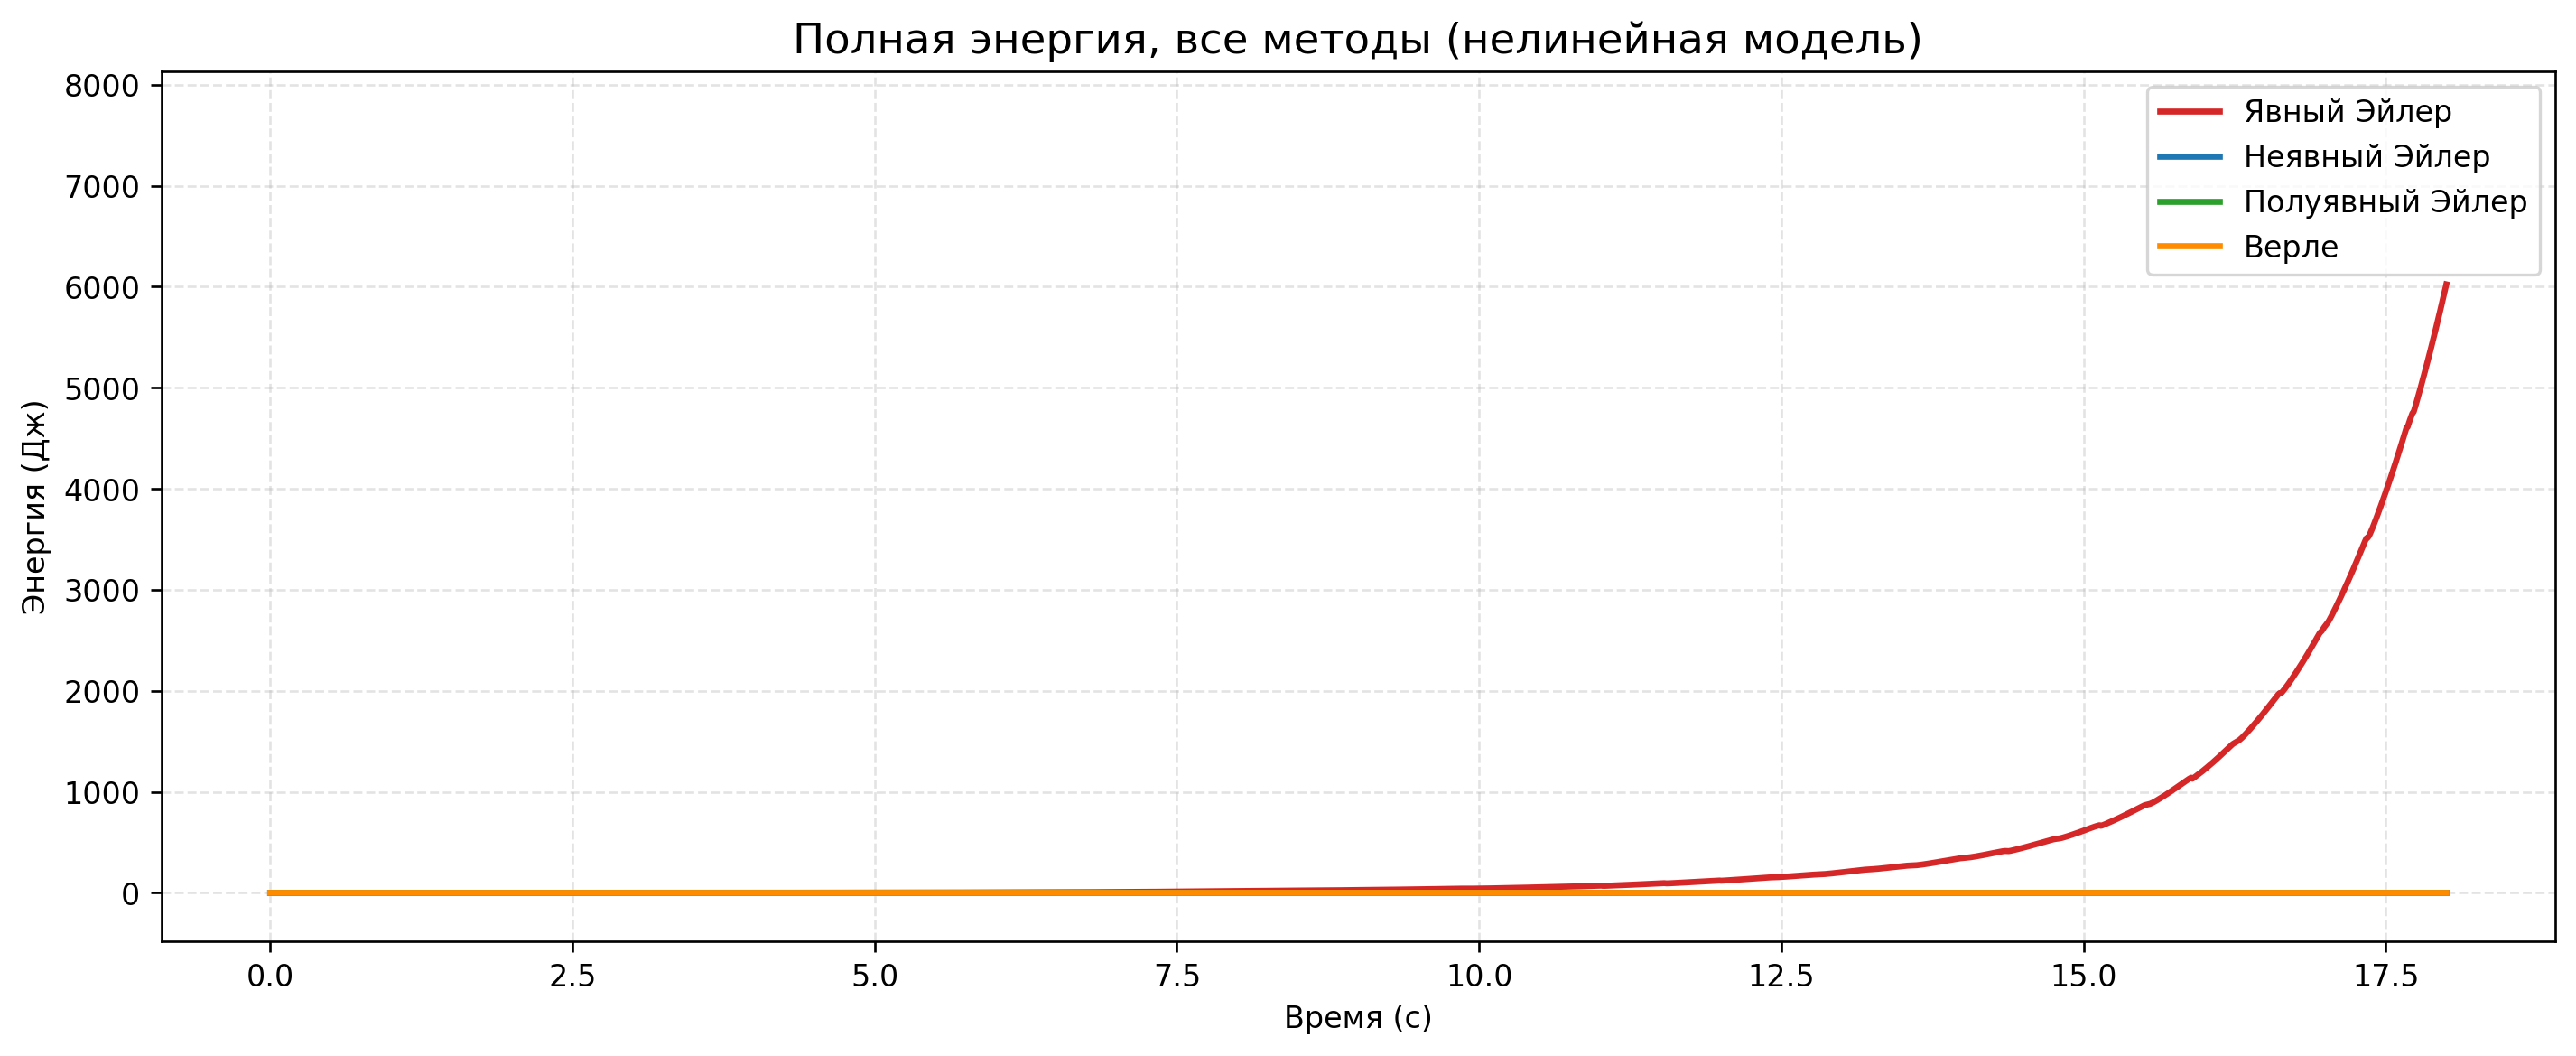

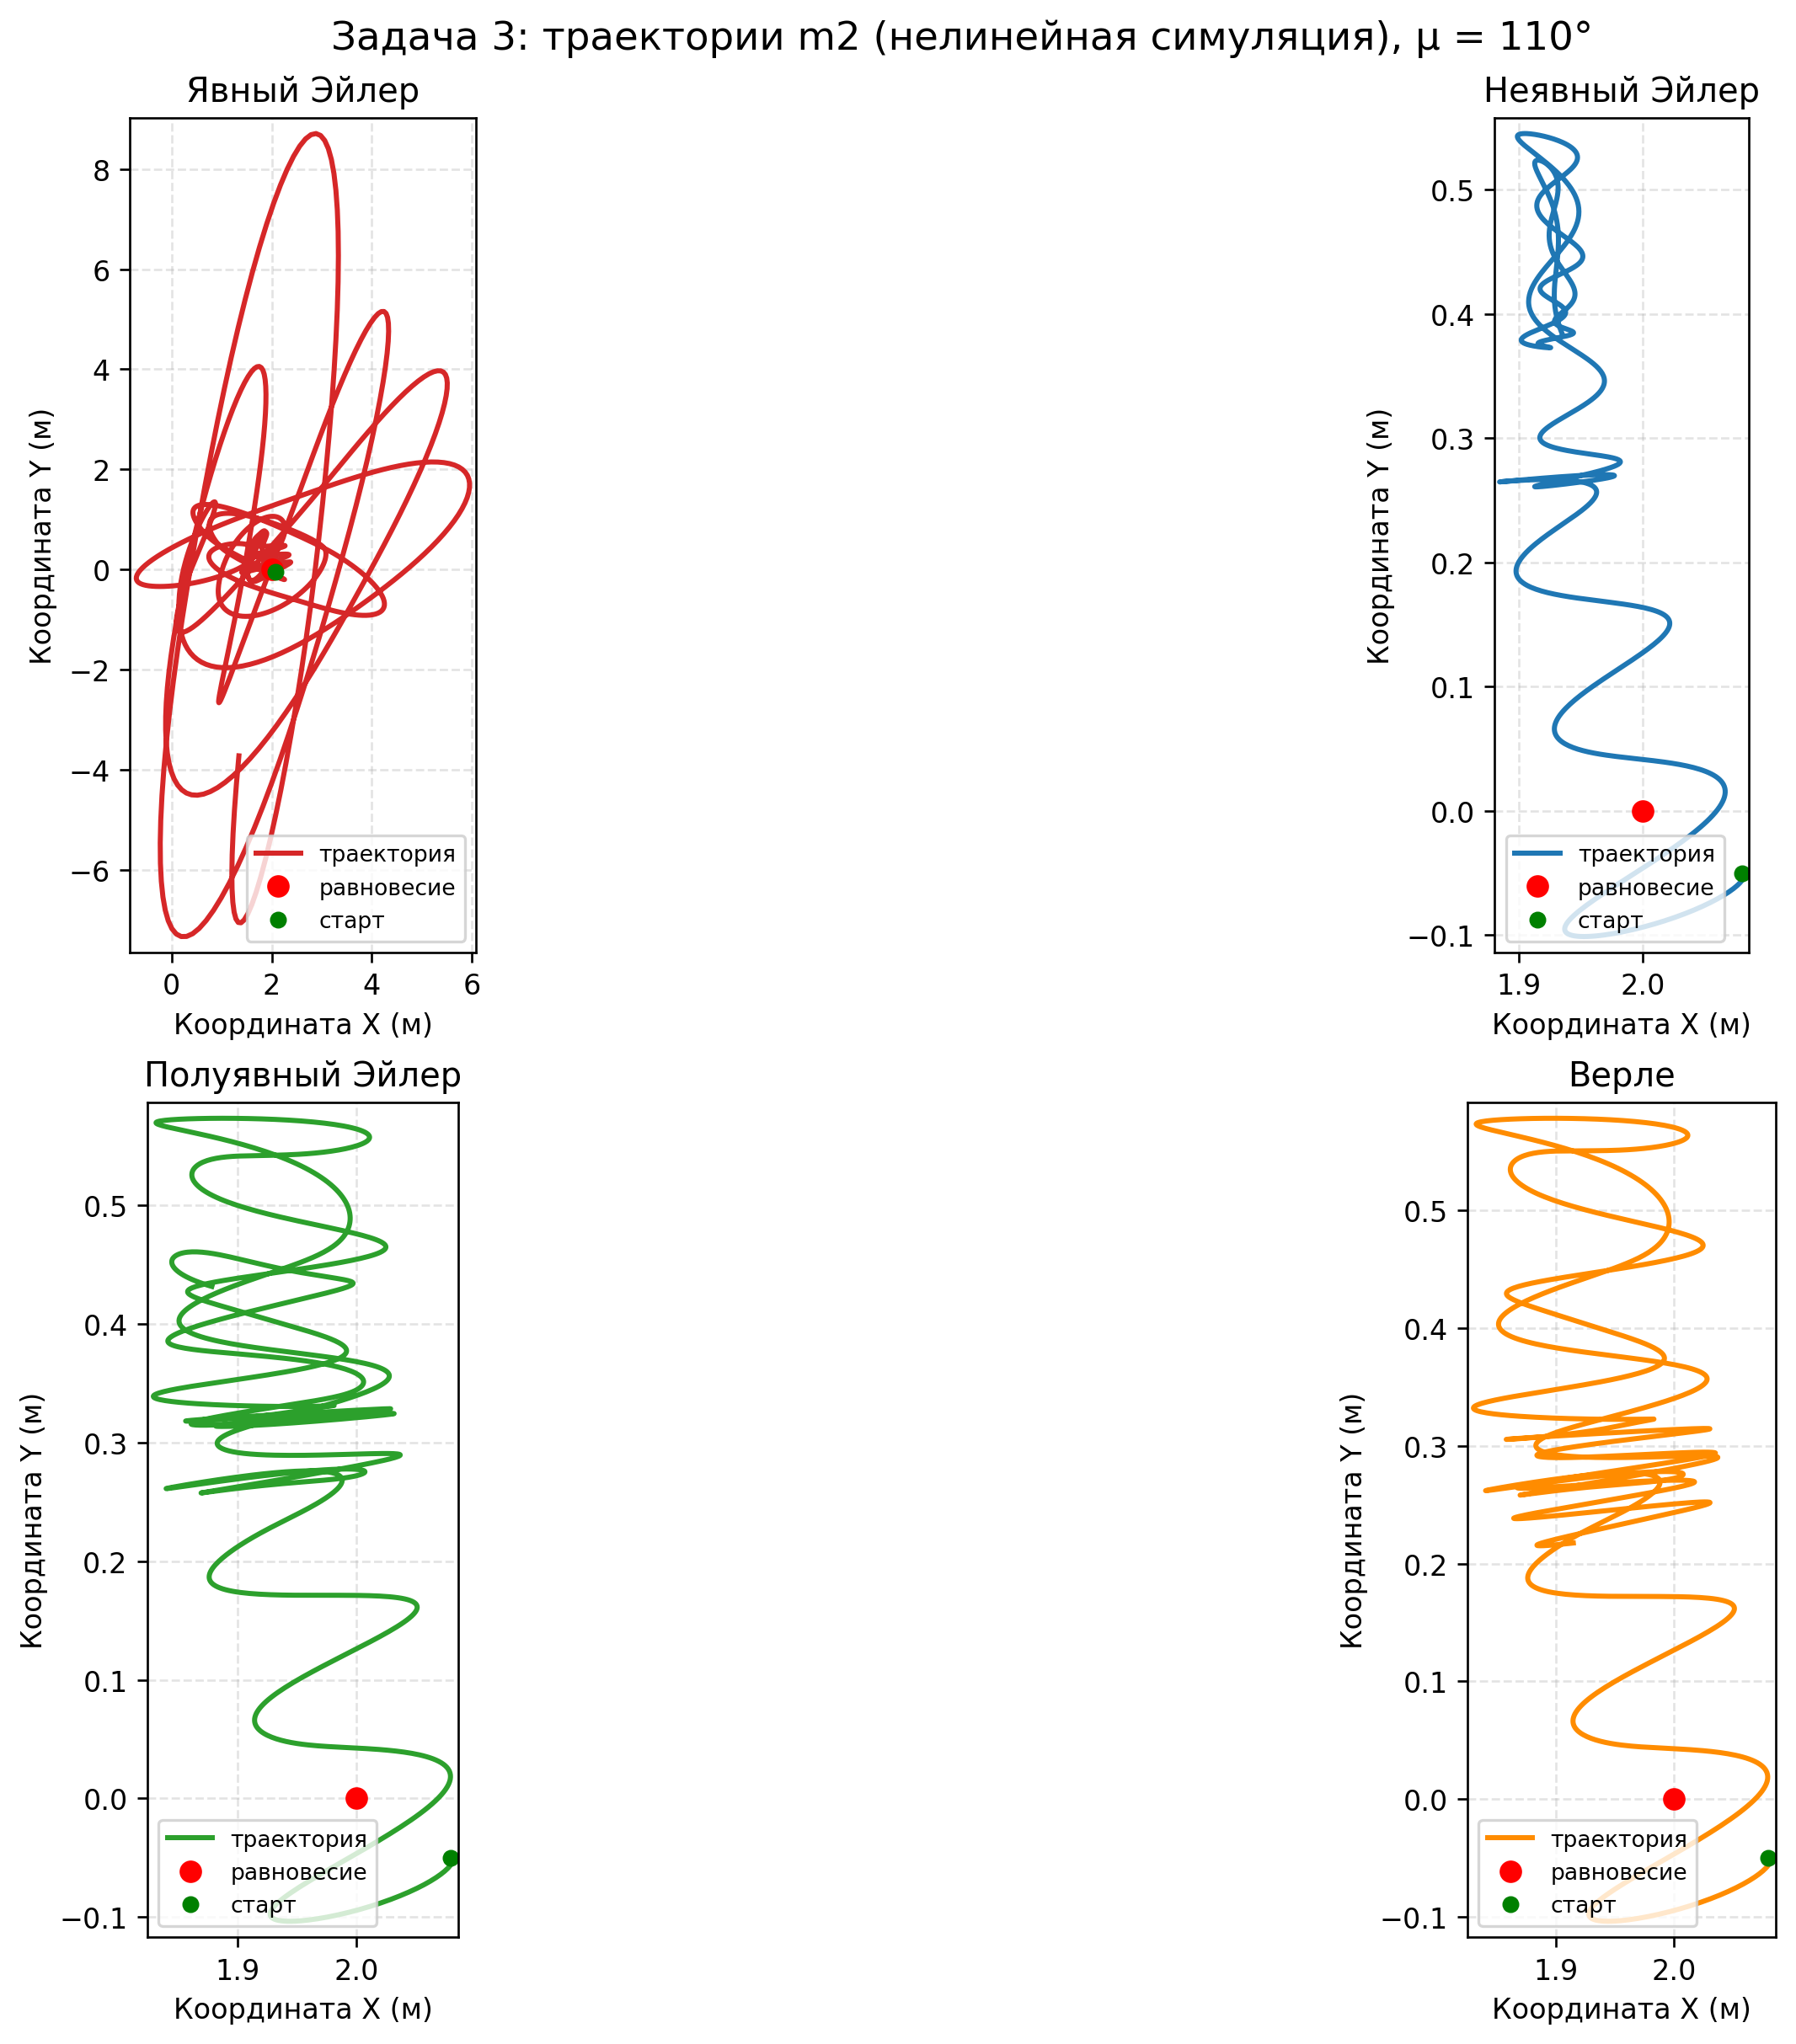

In [ ]:
colors = {
    "explicit": "tab:red",
    "implicit": "tab:blue",
    "semi": "tab:green",
    "verlet": "darkorange",
}

verlet_small = results_small["verlet"]
E_vs = verlet_small["E"]

# Энергия: аналитическая линеаризация vs малая нелинейная Верле
plt.figure(figsize=(12, 5))
plt.plot(ts, E_lin, color="black", lw=2, label="E_tot (линеаризация)")
plt.plot(time_small, E_vs, color="darkorange", lw=2, label="E_tot (нелинейно, Верле)")
plt.title("Энергия — линеаризация и малая нелинейная симуляция", fontsize=14)
plt.xlabel("Время (с)")
plt.ylabel("Энергия (Дж)")
plt.ylim(0, max(float(np.max(E_lin)), float(np.max(E_vs))) * 1.5 + 1e-15)
plt.grid(True, linestyle="--")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Траектория m2: аналитика vs малая Верле
plt.figure(figsize=(12, 5))
plt.plot(pos_lin[:, 2], pos_lin[:, 3], color="black", lw=2, ls="--", label="m2 (линеаризация)")
plt.plot(verlet_small["q"][:, 2], verlet_small["q"][:, 3], color="royalblue", lw=2, label="m2 (Верле)")
plt.plot(q_eq[2], q_eq[3], "ro", markersize=8, label="равновесие m2")
plt.title("Траектория правой массы (m2)", fontsize=14)
plt.xlabel("Координата X (м)")
plt.ylabel("Координата Y (м)")
plt.grid(True, linestyle="--")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

# Энергия: все методы
plt.figure(figsize=(12, 5))
for mid, r in results.items():
    plt.plot(time, r["E"], color=colors[mid], lw=2, label=r["label"])
plt.title("Полная энергия, все методы (нелинейная модель)", fontsize=14)
plt.xlabel("Время (с)")
plt.ylabel("Энергия (Дж)")
vals = np.concatenate([r["E"] for r in results.values()])
vals = vals[np.isfinite(vals)]
span = max(float(np.max(vals)) - float(np.min(vals)), 1e-12)
plt.ylim(float(np.min(vals)) - 0.08 * span, float(np.max(vals)) + 0.35 * span)
plt.grid(True, linestyle="--")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
method_order = ("explicit", "implicit", "semi", "verlet")
for ax, method_id in zip(axes.ravel(), method_order):
    r = results[method_id]
    q = r["q"]
    ax.plot(q[:, 2], q[:, 3], color=colors[method_id], lw=1.8, label="траектория")
    ax.plot(q_eq[2], q_eq[3], "ro", markersize=7, label="равновесие")
    ax.plot(q0_methods[2], q0_methods[3], "go", markersize=5, label="старт")
    ax.set_title(r["label"], fontsize=12)
    ax.set_xlabel("Координата X (м)")
    ax.set_ylabel("Координата Y (м)")
    ax.grid(True, linestyle="--")
    ax.legend(loc="best", fontsize=8)

    xs = q[:, 2]
    ys = q[:, 3]
    ok = np.isfinite(xs) & np.isfinite(ys)
    xs = np.append(xs[ok], [float(q_eq[2]), float(q0_methods[2])])
    ys = np.append(ys[ok], [float(q_eq[3]), float(q0_methods[3])])
    xmin, xmax = float(np.min(xs)), float(np.max(xs))
    ymin, ymax = float(np.min(ys)), float(np.max(ys))
    sx = max(xmax - xmin, 1e-9)
    sy = max(ymax - ymin, 1e-9)
    px = max(0.02 * sx, 1e-6)
    py = max(0.02 * sy, 1e-6)
    ax.set_xlim(xmin - px, xmax + px)
    ax.set_ylim(ymin - py, ymax + py)
    ax.set_aspect("equal", adjustable="box")

fig.suptitle("Траектории m2 (нелинейная симуляция), μ = 110°", fontsize=14)
plt.show()

## Выводы по графикам (task3)

- **Линеаризация:** при малых отклонениях энергия практически сохраняется, траектории двух масс остаются в малой окрестности равновесия.
- **Сопоставление с Верле:** для малых амплитуд траектория $m_2$ в нелинейной модели близка к траектории линеаризованной аналитики.
- **Сравнение методов:** явный Эйлер обычно показывает наиболее сильный энергетический дрейф, неявный — численное затухание, полуявный и Верле обычно стабильнее в колебательных системах.
